# Notebook 02 — Preprocess CogAge Atomic

**Purpose:** Parse, resample, and save the CogAge Atomic dataset  
in the unified per-stream format required by all downstream notebooks.

**Dataset characteristics:**
- 8 subjects, 61 activities, 10 repetitions each, 5-second duration per recording
- Session 1 = train, Session 2 = test (predefined — no random split)
- 9 sensor streams after removing 3 JINS blink/eye sensors
- Native frequencies: 20Hz (JINS), 50Hz (phone mag), 67Hz (watch), 200Hz (phone accel/gyro/gravity/linear)
- All resampled to 50Hz → each recording = exactly 250 samples → **no sliding window needed**
- Remove ALL folders/files containing `_r` (right hand)
- For `*` activities: left-hand only means keeping folders WITHOUT `_r` suffix

**Input root:**
```
/content/drive/MyDrive/Annonmazed_CogActivity/Sample/
```

**Folder naming convention:**
```
S{subject}_{ActivityName}_{session}_extracted        ← keep
S{subject}_{ActivityName}_{session}_extracted_r      ← skip (right hand)
```

**Output** (saved to `PROCESSED_PATHS['cogage_atomic']/`):
```
jins_accel.npy            (N, 250, 3)
jins_gyro.npy             (N, 250, 3)
phone_accel.npy           (N, 250, 3)
phone_gyro.npy            (N, 250, 3)
phone_gravity.npy         (N, 250, 3)
phone_linear_accel.npy    (N, 250, 3)
phone_magnetometer.npy    (N, 250, 3)
ms_accel.npy              (N, 250, 3)
ms_gyro.npy               (N, 250, 3)
y.npy                     (N,)  integer labels 0–60
subject_ids.npy           (N,)  subject IDs
stream_names.json
split_info.json           {train: [S1..], val: [S1..], test: [S1..]}
normalizers/              per-stream mean/std fitted on train subjects
```

---
**Run notebook 00 before this notebook.**

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

print('\n✅ Setup complete')
print(f'   Dataset : CogAge Atomic')
print(f'   Root    : {RAW_PATHS["cogage_atomic"]["root"]}')
print(f'   Output  : {PROCESSED_PATHS["cogage_atomic"]}')

Mounted at /content/drive
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subjects |  61 classes |  9 streams | n_way=5
   cogage_composite       →   6 subjects |   7 classes | 10 st

## Cell 2 — Sensor Stream Mapping

Maps sensor file name prefixes (as they appear in the folder)  
to our internal stream names and their native sampling frequencies.

**Sensors we KEEP (9):**
- JinsAccelerometer (20Hz)
- JinsGyroscope (20Hz)
- Accelerometer (phone, 200Hz)
- Gyroscope (phone, 200Hz)
- Gravity (phone, 200Hz)
- LinearAccelerometer (phone, 200Hz)
- Magnetometer (phone, 50Hz)
- MSAccelerometer (watch, 67Hz)
- MSGyroscope (watch, 67Hz)

**Sensors we REMOVE (3):**
- JinsBlinkStrength
- JinsEyeMovement
- JinsBlinkSpeed

In [ ]:
# Maps: file prefix (as it appears in folder) → (internal stream name, native freq)
# These are the prefixes of .data files inside each activity folder
SENSOR_FILE_MAP = {
    # JINS
    'JinsAccelerometer'    : ('jins_accel',          20),
    'JinsGyroscope'        : ('jins_gyro',           20),

    # PHONE
    'PhoneAccelerometer'   : ('phone_accel',         200),
    'PhoneGyroscope'       : ('phone_gyro',          200),
    'PhoneGravity'         : ('phone_gravity',       200),
    'PhoneLinearAccelerometer': ('phone_linear_accel', 200),
    'PhoneMagnetometer'    : ('phone_magnetometer',  50),

    # WATCH
    'android.sensor.accelerometer'      : ('ms_accel',            67),
    'android.sensor.gyroscope'          : ('ms_gyro',             67),
}

STREAM_NAMES   = [v[0] for v in SENSOR_FILE_MAP.values()]
STREAM_FREQS   = {v[0]: v[1] for v in SENSOR_FILE_MAP.values()}
FILE_PREFIXES  = list(SENSOR_FILE_MAP.keys())

print('✅ Sensor stream mapping defined')
print(f'   Streams to use ({len(STREAM_NAMES)}):')
for prefix, (stream_name, freq) in SENSOR_FILE_MAP.items():
    n_samples_after = int(5 * TARGET_FREQ)   # 5 sec × 50Hz = 250
    print(f'   {prefix:<25} → {stream_name:<22} {freq}Hz → {TARGET_FREQ}Hz = {n_samples_after} samples')

✅ Sensor stream mapping defined
   Streams to use (9):
   JinsAccelerometer         → jins_accel             20Hz → 50Hz = 250 samples
   JinsGyroscope             → jins_gyro              20Hz → 50Hz = 250 samples
   PhoneAccelerometer        → phone_accel            200Hz → 50Hz = 250 samples
   PhoneGyroscope            → phone_gyro             200Hz → 50Hz = 250 samples
   PhoneGravity              → phone_gravity          200Hz → 50Hz = 250 samples
   PhoneLinearAccelerometer  → phone_linear_accel     200Hz → 50Hz = 250 samples
   PhoneMagnetometer         → phone_magnetometer     50Hz → 50Hz = 250 samples
   android.sensor.accelerometer → ms_accel               67Hz → 50Hz = 250 samples
   android.sensor.gyroscope  → ms_gyro                67Hz → 50Hz = 250 samples


## Cell 3 — Scan Folder Structure

Discover all valid activity folders and parse their metadata  
from the naming convention `S{subject}_{ActivityName}_{session}_extracted`.

In [ ]:
import os
from typing import Optional, Dict

cfg  = DATASET_CONFIGS['cogage_atomic']
root = RAW_PATHS['cogage_atomic']['root']

# ─────────────────────────────────────────────────────────────────────────────
# 🔧 NORMALIZATION FUNCTION
# ─────────────────────────────────────────────────────────────────────────────
def normalize_activity_name(name: str) -> str:
    return name.strip().lower().replace('_', '').replace(' ', '')


# ─────────────────────────────────────────────────────────────────────────────
# 🔍 HELPER: VALID FOLDER CHECK
# ─────────────────────────────────────────────────────────────────────────────
def is_valid_folder(name: str) -> bool:
    return (
        name.endswith('_extracted')
        and not name.endswith('_r')
        and '_extracted_r' not in name
    )


# ─────────────────────────────────────────────────────────────────────────────
# 🔥 AUTO-BUILD ACTIVITY MAP FROM DATA
# ─────────────────────────────────────────────────────────────────────────────
all_activity_names = set()

for folder_name in os.listdir(root):
    if not is_valid_folder(folder_name):
        continue

    core  = folder_name[:-len('_extracted')]
    parts = core.split('_')

    if len(parts) < 3:
        continue

    raw_activity  = '_'.join(parts[1:-1])
    norm_activity = normalize_activity_name(raw_activity)

    if norm_activity:  # extra safety
        all_activity_names.add(norm_activity)

# Sort for consistent labeling
all_activity_names = sorted(all_activity_names)

# Final mapping
act_name_to_int = {name: idx for idx, name in enumerate(all_activity_names)}

print('✅ Auto-built activity map')
print(f'   Unique normalized activities: {len(act_name_to_int)}')


# ─────────────────────────────────────────────────────────────────────────────
# 📦 PARSER
# ─────────────────────────────────────────────────────────────────────────────
def parse_folder_name(folder_name: str) -> Optional[Dict]:
    if not is_valid_folder(folder_name):
        return None

    core  = folder_name[:-len('_extracted')]
    parts = core.split('_')

    if len(parts) < 3:
        return None

    # ─── Subject ─────────────────────────────────────────────────────────────
    subj_part = parts[0]
    if not (subj_part.startswith('S') and subj_part[1:].isdigit()):
        return None
    subject_id = int(subj_part[1:])

    # ─── Session ─────────────────────────────────────────────────────────────
    session_part = parts[-1]
    if session_part not in ('1', '2'):
        return None
    session = int(session_part)

    # ─── Activity ────────────────────────────────────────────────────────────
    raw_activity  = '_'.join(parts[1:-1])
    norm_activity = normalize_activity_name(raw_activity)

    # Safety check (should always exist, but prevents crash)
    if norm_activity not in act_name_to_int:
        return None

    label = act_name_to_int[norm_activity]

    return {
        'subject_id'    : subject_id,
        'activity_name' : raw_activity,
        'activity_norm' : norm_activity,
        'session'       : session,
        'label'         : label,
        'folder_name'   : folder_name,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 📂 SCAN ALL FOLDERS
# ─────────────────────────────────────────────────────────────────────────────
print(f'\nScanning: {root}\n')

valid_folders = []
skipped_r     = 0
skipped_other = 0

for folder_name in sorted(os.listdir(root)):
    folder_path = os.path.join(root, folder_name)

    if not os.path.isdir(folder_path):
        continue

    if not is_valid_folder(folder_name):
        if folder_name.endswith('_r') or '_extracted_r' in folder_name:
            skipped_r += 1
        else:
            skipped_other += 1
        continue

    meta = parse_folder_name(folder_name)

    if meta is None:
        skipped_other += 1
        continue

    meta['folder_path'] = folder_path
    valid_folders.append(meta)


# ─────────────────────────────────────────────────────────────────────────────
# 📊 SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
subjects_found = sorted({m['subject_id'] for m in valid_folders})
activities_found = sorted({m['activity_norm'] for m in valid_folders})
sessions_found = sorted({m['session'] for m in valid_folders})

print(f'   Valid folders  : {len(valid_folders)}')
print(f'   Skipped (_r)   : {skipped_r}')
print(f'   Skipped (other): {skipped_other}')

print(f'\n   Subjects found  : {subjects_found}')
print(f'   Activities found: {len(activities_found)}')
print(f'   Sessions found  : {sessions_found}  (1=train, 2=test)')

expected = len(subjects_found) * len(activities_found) * 2

print(f'\n   Expected ~{expected} folders')
print(f'   Got             : {len(valid_folders)} folders')

✅ Auto-built activity map
   Unique normalized activities: 61

Scanning: /content/drive/MyDrive/Annonmazed_CogActivity/Sample/

   Valid folders  : 881
   Skipped (_r)   : 519
   Skipped (other): 2

   Subjects found  : [1, 2, 3, 4, 5, 6, 7, 8]
   Activities found: 61
   Sessions found  : [1, 2]  (1=train, 2=test)

   Expected ~976 folders
   Got             : 881 folders


## Cell 4 — Parse One Data File

CogAge Atomic sensor file format:
```
1520437129802;1.0;-6.0;-13.0
1520437129838;1.0;-6.0;-13.0
```
Fields: `timestamp_ms;x;y;z` — semicolon separated, no header.

In [ ]:
def parse_cogage_atomic_sensor_file(filepath: str) -> Optional[np.ndarray]:
    """
    Parse one CogAge Atomic sensor .data file.

    Args:
        filepath : path to a .data file

    Returns:
        (T, 3) float32 array of [x, y, z] values, or None if file is empty/corrupt

    Notes:
        - Timestamp column is discarded — only x, y, z kept
        - Lines that cannot be parsed are skipped
        - Returns None if fewer than 2 valid rows
    """
    rows = []
    try:
        with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split(';')
                if len(parts) < 4:
                    continue
                try:
                    x = float(parts[1])
                    y = float(parts[2])
                    z = float(parts[3])
                    rows.append([x, y, z])
                except ValueError:
                    continue
    except (IOError, OSError):
        return None

    if len(rows) < 2:
        return None

    return np.array(rows, dtype=np.float32)


def find_sensor_file(
    folder_path  : str,
    file_prefix  : str,
    repetition   : int
) -> Optional[str]:
    """
    Find the sensor file for a given prefix and repetition index.

    CogAge Atomic stores repetitions as:
        JinsAccelerometer_Event_0.data
        JinsAccelerometer_Event_1.data  etc.

    Args:
        folder_path : path to the activity folder
        file_prefix : e.g. 'JinsAccelerometer'
        repetition  : 0–9

    Returns:
        Full file path if found, else None
    """
    filename = f'{file_prefix}_Event_{repetition}.data'
    fullpath = os.path.join(folder_path, filename)
    if os.path.isfile(fullpath):
        return fullpath
    return None


# ─── Quick test on first valid folder ─────────────────────────────────────────
if valid_folders:
    test_meta = valid_folders[0]
    test_fp   = find_sensor_file(test_meta['folder_path'], 'JinsAccelerometer', 0)
    if test_fp:
        test_data = parse_cogage_atomic_sensor_file(test_fp)
        print(f'✅ Parser test OK')
        print(f'   File   : {test_fp}')
        print(f'   Shape  : {test_data.shape if test_data is not None else None}')
        print(f'   Sample : {test_data[:3] if test_data is not None else None}')
    else:
        print(f'⚠ Could not find test file in {test_meta["folder_path"]}')
        print(f'  Files present: {os.listdir(test_meta["folder_path"])[:5]}')

✅ Parser test OK
   File   : /content/drive/MyDrive/Annonmazed_CogActivity/Sample/S1_Bending_1_extracted/JinsAccelerometer_Event_0.data
   Shape  : (100, 3)
   Sample : [[-7. 15. -1.]
 [-7. 14. -1.]
 [-7. 14. -1.]]


## Cell 5 — Discover Repetition Structure

Each folder contains 10 repetitions (Event_0 to Event_9) per sensor.  
Check how many repetitions are actually present and if they are consistent.

In [ ]:
# Check repetitions available in the first few folders
print('Checking repetition structure on a sample of folders...\n')

MAX_REPS   = 10   # 0–9 per the dataset spec
sample_n   = min(5, len(valid_folders))

for meta in valid_folders[:sample_n]:
    folder_path = meta['folder_path']
    prefix      = 'JinsAccelerometer'   # use JINS as reference
    found_reps  = [
        r for r in range(MAX_REPS)
        if find_sensor_file(folder_path, prefix, r) is not None
    ]
    print(f'   {meta["folder_name"]:<55} → reps found: {found_reps}')

print(f'\n✅ Will iterate repetitions 0–{MAX_REPS-1} and skip any missing files')

Checking repetition structure on a sample of folders...

   S1_Bending_1_extracted                                  → reps found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   S1_Bending_2_extracted                                  → reps found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   S1_Bring_1_extracted                                    → reps found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   S1_Bring_2_extracted                                    → reps found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   S1_CleanFloor_1_extracted                               → reps found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

✅ Will iterate repetitions 0–9 and skip any missing files


## Cell 6 — Main Processing Loop

For each valid folder (subject × activity × session):  
1. For each repetition (0–9):  
   a. Load all 9 sensor files  
   b. Resample each to 50Hz → 250 samples  
   c. If any stream is missing or too short → skip this repetition  
   d. Store as one sample across all 9 streams  

**No sliding window needed** — each 5-second recording is already one sample.

In [ ]:
# ─── Accumulators ─────────────────────────────────────────────────────────────
stream_samples : Dict[str, list] = {s: [] for s in STREAM_NAMES}
all_labels      = []
all_subject_ids = []
all_sessions    = []   # keep track for split construction

n_total    = 0
n_skipped  = 0
skip_log   = []    # detailed skip reasons (capped at 50 entries)

EXPECTED_SAMPLES = WINDOW_SIZE   # 250 after resampling to 50Hz for 5 sec

print(f'Processing {len(valid_folders)} folders × up to {MAX_REPS} repetitions...')
print(f'All streams will be standardized to {EXPECTED_SAMPLES} samples')
print()

for meta in valid_folders:
    folder_path   = meta['folder_path']
    subject_id    = meta['subject_id']
    activity_name = meta['activity_name']
    session       = meta['session']
    label         = meta['label']

    for rep in range(MAX_REPS):

        # ── Load all 9 streams for this repetition ────────────────────────────
        sample_streams = {}
        skip_reason    = None

        for file_prefix, (stream_name, native_freq) in SENSOR_FILE_MAP.items():

            fpath = find_sensor_file(folder_path, file_prefix, rep)

            if fpath is None:
                skip_reason = f'missing file: {file_prefix}_Event_{rep}.data'
                break

            raw_data = parse_cogage_atomic_sensor_file(fpath)

            if raw_data is None or len(raw_data) < 5:
                skip_reason = f'empty/corrupt file: {file_prefix}_Event_{rep}.data'
                break

            try:
                # 🔥 STEP 1: Resample to 50Hz
                resampled = resample_stream(raw_data, src_freq=native_freq)

                # 🔥 STEP 2: FORCE exact length (CRITICAL FIX)
                if len(resampled) != EXPECTED_SAMPLES:
                    from scipy.signal import resample
                    resampled = resample(resampled, EXPECTED_SAMPLES, axis=0)

                # 🔥 STEP 3: Safety check
                if np.isnan(resampled).any():
                    skip_reason = f'nan values after resampling: {file_prefix}'
                    break

                sample_streams[stream_name] = resampled.astype(np.float32)

            except Exception as e:
                skip_reason = f'processing error: {file_prefix} ({str(e)})'
                break

        # ── Skip if any stream failed ─────────────────────────────────────────
        if skip_reason is not None or len(sample_streams) != len(STREAM_NAMES):
            n_skipped += 1
            if len(skip_log) < 50:
                skip_log.append({
                    'subject'  : subject_id,
                    'activity' : activity_name,
                    'session'  : session,
                    'rep'      : rep,
                    'reason'   : skip_reason or 'incomplete streams',
                })
            continue

        # ── Store this repetition as one sample ───────────────────────────────
        for stream_name in STREAM_NAMES:
            stream_samples[stream_name].append(sample_streams[stream_name])

        all_labels.append(label)
        all_subject_ids.append(subject_id)
        all_sessions.append(session)
        n_total += 1

print(f'\n── Results ──')
print(f'   Total samples collected : {n_total:,}')
print(f'   Skipped repetitions     : {n_skipped}')

if skip_log:
    print(f'\n   Skip log (first {len(skip_log)}):')
    for entry in skip_log[:10]:
        print(f'     S{entry["subject"]} | {entry["activity"]:<30} | '
              f'session={entry["session"]} rep={entry["rep"]} | {entry["reason"]}')

print(f'\n✅ Main loop complete')

Processing 881 folders × up to 10 repetitions...
All streams will be standardized to 250 samples


── Results ──
   Total samples collected : 7,277
   Skipped repetitions     : 1533

   Skip log (first 50):
     S1 | CleanSurface                   | session=1 rep=7 | missing file: JinsAccelerometer_Event_7.data
     S1 | CleanSurface                   | session=1 rep=8 | missing file: JinsAccelerometer_Event_8.data
     S1 | CleanSurface                   | session=1 rep=9 | missing file: JinsAccelerometer_Event_9.data
     S1 | CleanSurface                   | session=2 rep=7 | missing file: JinsAccelerometer_Event_7.data
     S1 | CleanSurface                   | session=2 rep=8 | missing file: JinsAccelerometer_Event_8.data
     S1 | CleanSurface                   | session=2 rep=9 | missing file: JinsAccelerometer_Event_9.data
     S1 | CloseDoor                      | session=1 rep=7 | missing file: JinsAccelerometer_Event_7.data
     S1 | CloseDoor                      | session=

## Cell 7 — Stack into Final Arrays

In [ ]:
print('Stacking into final arrays...')

final_streams : Dict[str, np.ndarray] = {}
for stream_name in STREAM_NAMES:
    arr = np.stack(stream_samples[stream_name], axis=0).astype(np.float32)
    final_streams[stream_name] = arr
    print(f'   {stream_name:<22} → {arr.shape}')

final_y           = np.array(all_labels,      dtype=np.int64)
final_subject_ids = np.array(all_subject_ids, dtype=object)
final_sessions    = np.array(all_sessions,    dtype=np.int64)

print(f'   y              → {final_y.shape}  | unique labels: {np.unique(final_y)}')
print(f'   subject_ids    → {final_subject_ids.shape}')
print(f'   sessions       → {final_sessions.shape} | unique: {np.unique(final_sessions)}')

# Sanity checks
ns = [v.shape[0] for v in final_streams.values()]
assert len(set(ns)) == 1, f'Stream lengths differ: {dict(zip(STREAM_NAMES, ns))}'
assert ns[0] == len(final_y) == len(final_subject_ids), 'Length mismatch'
assert all(v.shape[1] == EXPECTED_SAMPLES for v in final_streams.values()), 'Wrong sample count'
assert all(v.shape[2] == 3 for v in final_streams.values()), 'Wrong n_axes'

print(f'\n✅ Arrays consistent — N={ns[0]:,} samples, shape ({EXPECTED_SAMPLES}, 3) per stream')

Stacking into final arrays...
   jins_accel             → (7277, 250, 3)
   jins_gyro              → (7277, 250, 3)
   phone_accel            → (7277, 250, 3)
   phone_gyro             → (7277, 250, 3)
   phone_gravity          → (7277, 250, 3)
   phone_linear_accel     → (7277, 250, 3)
   phone_magnetometer     → (7277, 250, 3)
   ms_accel               → (7277, 250, 3)
   ms_gyro                → (7277, 250, 3)
   y              → (7277,)  | unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60]
   subject_ids    → (7277,)
   sessions       → (7277,) | unique: [1 2]

✅ Arrays consistent — N=7,277 samples, shape (250, 3) per stream


## Cell 8 — Build Train / Val / Test Split

**CogAge Atomic has a predefined session split:**
- Session 1 = train data
- Session 2 = test data

We respect this predefined split. Validation is carved out  
from train subjects (not train samples) to avoid leakage.

In [ ]:
all_subj_ids = sorted(np.unique(final_subject_ids).tolist())
print(f'All subjects: {all_subj_ids}')

# ─── Use session to define train vs test ──────────────────────────────────────
# Session 1 → train+val pool
# Session 2 → test
train_val_mask = (final_sessions == 1)
test_mask      = (final_sessions == 2)

# ─── Carve out val subjects from train pool ───────────────────────────────────
# Val subjects are withheld from training entirely (user-level)
# We take ~12.5% of subjects as val, their session 1 data becomes val
n_val_subjects = max(1, int(round(len(all_subj_ids) * SPLIT_VAL)))

rng = np.random.default_rng(MASTER_SEED)
shuffled_subjs = all_subj_ids.copy()
rng.shuffle(shuffled_subjs)

val_subjects   = shuffled_subjs[:n_val_subjects]
train_subjects = [s for s in shuffled_subjs[n_val_subjects:] ]
test_subjects  = all_subj_ids   # all subjects appear in test (session 2)

# Build masks combining session and subject
val_subj_mask  = get_split_mask(final_subject_ids, val_subjects)
train_subj_mask= get_split_mask(final_subject_ids, train_subjects)

train_final_mask = train_subj_mask & train_val_mask
val_final_mask   = val_subj_mask   & train_val_mask
test_final_mask  = test_mask

split_info = {
    'train'   : [int(s) for s in train_subjects],
    'val'     : [int(s) for s in val_subjects],
    'test'    : [int(s) for s in all_subj_ids],   # session 2 for all subjects
    'note'    : 'CogAge Atomic uses predefined session split. '
                'Session 1 = train+val pool. Session 2 = test. '
                'Val subjects are excluded from training.'
}

print(f'\n── Split summary ──')
for split_name, mask in [('train', train_final_mask),
                          ('val',   val_final_mask),
                          ('test',  test_final_mask)]:
    n_samples = mask.sum()
    subjs     = np.unique(final_subject_ids[mask]).tolist()
    n_classes = len(np.unique(final_y[mask]))
    print(f'   {split_name:<6}: {n_samples:>5} samples | {n_classes:>2} classes | subjects: {subjs}')

# Verify no leakage
assert not (train_final_mask & val_final_mask).any(), 'Leakage: train/val'
print('\n✅ No leakage between splits')

All subjects: [1, 2, 3, 4, 5, 6, 7, 8]

── Split summary ──
   train :  3366 samples | 60 classes | subjects: [1, 2, 3, 5, 6, 7, 8]
   val   :   529 samples | 59 classes | subjects: [4]
   test  :  3382 samples | 60 classes | subjects: [1, 2, 3, 5, 6, 7, 8]

✅ No leakage between splits


## Cell 9 — Per-Stream Normalisation
Fit on train samples only. Apply to all.

In [ ]:
normalizer_dir = os.path.join(PROCESSED_PATHS['cogage_atomic'], 'normalizers')
os.makedirs(normalizer_dir, exist_ok=True)

print('Fitting per-stream normalisers on train samples only...')

normalized_streams : Dict[str, np.ndarray] = {}

for stream_name, arr in final_streams.items():
    norm = StreamNormalizer()
    norm.fit(arr[train_final_mask])
    arr_norm = norm.transform(arr)
    normalized_streams[stream_name] = arr_norm

    norm_path = os.path.join(normalizer_dir, stream_name)
    norm.save(norm_path)

    train_mean = arr_norm[train_final_mask].mean()
    train_std  = arr_norm[train_final_mask].std()
    print(f'   {stream_name:<22} → train mean={train_mean:.4f} | train std={train_std:.4f}')

print(f'\n✅ Normalisation done')

Fitting per-stream normalisers on train samples only...
   jins_accel             → train mean=-0.0000 | train std=1.0006
   jins_gyro              → train mean=-0.0001 | train std=1.0002
   phone_accel            → train mean=0.0000 | train std=1.0002
   phone_gyro             → train mean=-0.0000 | train std=1.0006
   phone_gravity          → train mean=0.0002 | train std=1.0002
   phone_linear_accel     → train mean=0.0000 | train std=1.0009
   phone_magnetometer     → train mean=-0.0000 | train std=1.0002
   ms_accel               → train mean=-0.0000 | train std=1.0002
   ms_gyro                → train mean=-0.0000 | train std=1.0005

✅ Normalisation done


## Cell 10 — Save Processed Dataset

In [ ]:
print('Saving processed CogAge Atomic dataset...')

save_processed_dataset(
    dataset_name  = 'cogage_atomic',
    stream_arrays = normalized_streams,
    y             = final_y,
    subject_ids   = final_subject_ids,
    stream_names  = STREAM_NAMES,
    split_info    = split_info,
)

# Also save session labels — useful for debugging and analysis
np.save(
    os.path.join(PROCESSED_PATHS['cogage_atomic'], 'sessions.npy'),
    final_sessions
)
print('   Saved sessions.npy')

Saving processed CogAge Atomic dataset...
   Saved stream jins_accel                → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/jins_accel.npy
   Saved stream jins_gyro                 → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/jins_gyro.npy
   Saved stream phone_accel               → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/phone_accel.npy
   Saved stream phone_gyro                → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/phone_gyro.npy
   Saved stream phone_gravity             → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/phone_gravity.npy
   Saved stream phone_linear_accel        → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/phone_linear_accel.npy
   Saved stream phone_magnetometer        → (7277, 250, 3)  →  /content/drive/MyDrive/fsl_har_processed/cogage_atomic/phone_magnetometer.npy
   Saved

## Cell 11 — Verification: Load and Sanity Check

In [ ]:
print('Verifying saved dataset...\n')

loaded = load_processed_dataset('cogage_atomic')

print('── Shapes ──')
for name, arr in loaded['streams'].items():
    print(f'   {name:<22} : {arr.shape}  dtype={arr.dtype}')

print(f'   y              : {loaded["y"].shape}')
print(f'   subject_ids    : {loaded["subject_ids"].shape}')

print('\n── Label coverage ──')
labels_found = sorted(np.unique(loaded['y']).tolist())
labels_expected = list(range(61))
missing_labels = [l for l in labels_expected if l not in labels_found]
print(f'   Labels found    : {len(labels_found)} / 61')
if missing_labels:
    print(f'   ⚠ Missing labels: {missing_labels}')
    for l in missing_labels:
        print(f'      [{l}] {cfg["activity_labels"][l]}')
else:
    print('   ✅ All 61 activity labels present')

print('\n── Samples per subject ──')
for subj in sorted(np.unique(loaded['subject_ids']).tolist()):
    mask   = loaded['subject_ids'] == subj
    n_samp = mask.sum()
    n_cls  = len(np.unique(loaded['y'][mask]))
    print(f'   Subject {subj}: {n_samp:>4} samples | {n_cls:>2} activities')

print('\n── Consistency checks ──')
ns = [v.shape[0] for v in loaded['streams'].values()]
assert len(set(ns)) == 1
assert ns[0] == len(loaded['y'])
assert all(v.shape[1] == WINDOW_SIZE for v in loaded['streams'].values())
assert all(v.shape[2] == 3 for v in loaded['streams'].values())
print('   ✅ All checks passed')

Verifying saved dataset...

✅ Loaded "cogage_atomic" — 7277 windows | 9 streams
── Shapes ──
   jins_accel             : (7277, 250, 3)  dtype=float32
   jins_gyro              : (7277, 250, 3)  dtype=float32
   phone_accel            : (7277, 250, 3)  dtype=float32
   phone_gyro             : (7277, 250, 3)  dtype=float32
   phone_gravity          : (7277, 250, 3)  dtype=float32
   phone_linear_accel     : (7277, 250, 3)  dtype=float32
   phone_magnetometer     : (7277, 250, 3)  dtype=float32
   ms_accel               : (7277, 250, 3)  dtype=float32
   ms_gyro                : (7277, 250, 3)  dtype=float32
   y              : (7277,)
   subject_ids    : (7277,)

── Label coverage ──
   Labels found    : 61 / 61
   ✅ All 61 activity labels present

── Samples per subject ──
   Subject 1:  985 samples | 59 activities
   Subject 2:  833 samples | 58 activities
   Subject 3:  964 samples | 59 activities
   Subject 4:  529 samples | 59 activities
   Subject 5: 1070 samples | 59 activities


## Cell 12 — Verification Plots

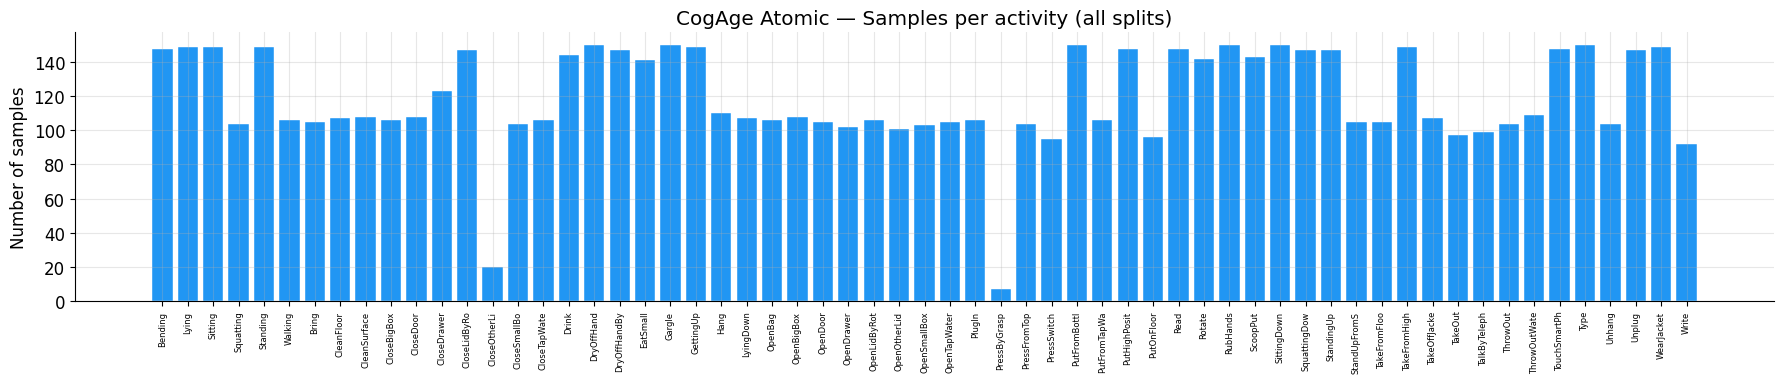

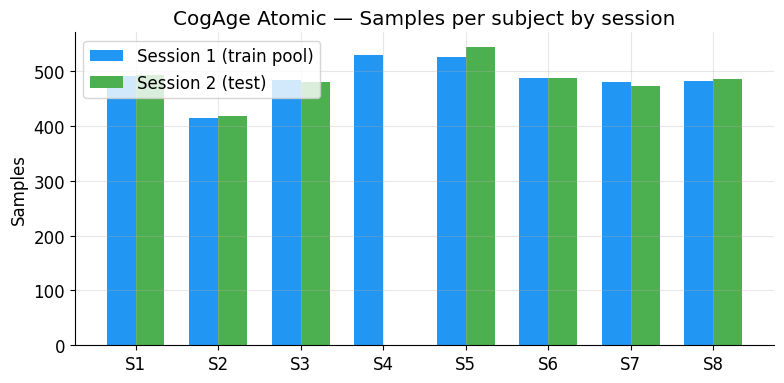

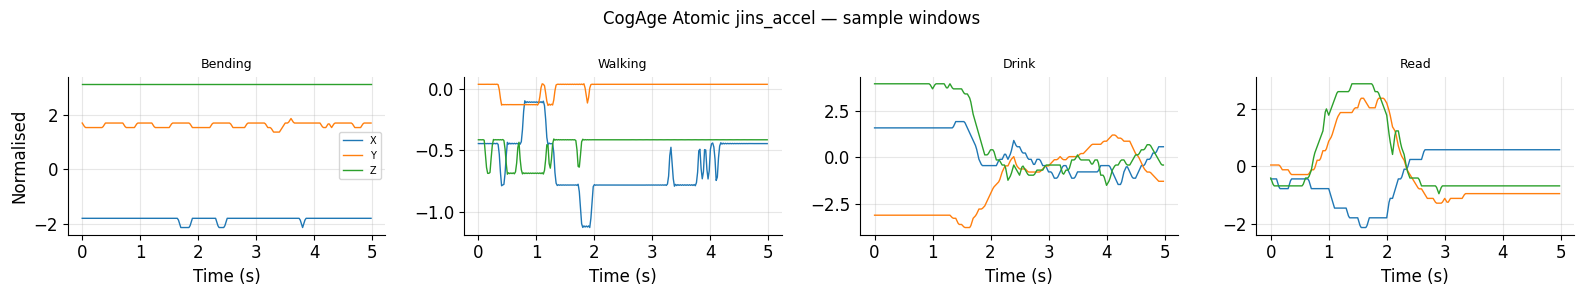

In [ ]:
y_loaded   = loaded['y']
sub_loaded = loaded['subject_ids']

# ─── Plot 1: Samples per activity ─────────────────────────────────────────────
act_counts = [(y_loaded == i).sum() for i in range(61)]
act_labels_short = [cfg['activity_labels'][i][:12] for i in range(61)]

fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(range(61), act_counts, color='#2196F3', edgecolor='white', linewidth=0.3)
ax.set_xticks(range(61))
ax.set_xticklabels(act_labels_short, rotation=90, fontsize=6)
ax.set_ylabel('Number of samples')
ax.set_title('CogAge Atomic — Samples per activity (all splits)')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['cogage_atomic'], 'plot_class_distribution.png'), dpi=120)
plt.show()

# ─── Plot 2: Samples per subject × session ────────────────────────────────────
sessions_loaded = np.load(os.path.join(PROCESSED_PATHS['cogage_atomic'], 'sessions.npy'))
subjects_uniq   = sorted(np.unique(sub_loaded).tolist())

fig, ax = plt.subplots(figsize=(8, 4))
x       = np.arange(len(subjects_uniq))
width   = 0.35
s1_counts = [(sub_loaded[sessions_loaded == 1] == s).sum() for s in subjects_uniq]
s2_counts = [(sub_loaded[sessions_loaded == 2] == s).sum() for s in subjects_uniq]
ax.bar(x - width/2, s1_counts, width, label='Session 1 (train pool)', color='#2196F3')
ax.bar(x + width/2, s2_counts, width, label='Session 2 (test)',        color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels([f'S{s}' for s in subjects_uniq])
ax.set_ylabel('Samples')
ax.set_title('CogAge Atomic — Samples per subject by session')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['cogage_atomic'], 'plot_subject_sessions.png'), dpi=120)
plt.show()

# ─── Plot 3: Sample windows from jins_accel for 4 activities ──────────────────
sample_stream  = loaded['streams']['jins_accel']
sample_acts    = [0, 5, 16, 40]   # Bending, Walking, Drink, Read
t              = np.arange(WINDOW_SIZE) / TARGET_FREQ

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, act_id in zip(axes, sample_acts):
    mask = (y_loaded == act_id)
    if mask.sum() == 0:
        ax.set_title('No data')
        continue
    win = sample_stream[mask][0]
    ax.plot(t, win[:, 0], label='X', linewidth=1)
    ax.plot(t, win[:, 1], label='Y', linewidth=1)
    ax.plot(t, win[:, 2], label='Z', linewidth=1)
    ax.set_title(cfg['activity_labels'][act_id], fontsize=9)
    ax.set_xlabel('Time (s)')
    if ax is axes[0]:
        ax.set_ylabel('Normalised')
        ax.legend(fontsize=7)

fig.suptitle('CogAge Atomic jins_accel — sample windows', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_PATHS['cogage_atomic'], 'plot_sample_windows.png'), dpi=120)
plt.show()

## Cell 13 — Final Summary

In [ ]:
N = loaded['y'].shape[0]

print('=' * 60)
print('  CogAge ATOMIC PREPROCESSING COMPLETE')
print('=' * 60)
print(f'  Total samples      : {N:,}')
print(f'  Streams            : {len(STREAM_NAMES)}')
for s in STREAM_NAMES:
    print(f'    {s}')
print(f'  Sample shape       : ({WINDOW_SIZE}, 3) @ {TARGET_FREQ}Hz')
print(f'  Classes            : {len(np.unique(loaded["y"]))} activities')
print(f'  Subjects           : {len(all_subj_ids)}')
print(f'    Train subjects   : {sorted(train_subjects)}')
print(f'    Val subjects     : {sorted(val_subjects)}')
print(f'    Test subjects    : all (session 2)')
print(f'  Skipped reps       : {n_skipped}')
print(f'  Saved to           : {PROCESSED_PATHS["cogage_atomic"]}')
print('=' * 60)
print()
print('  Files saved:')
for fname in sorted(os.listdir(PROCESSED_PATHS['cogage_atomic'])):
    fpath = os.path.join(PROCESSED_PATHS['cogage_atomic'], fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'    {fname:<40} {size_mb:.2f} MB')
print()
print('  ✅ Ready — continue with notebooks 03, 04')
print('     or jump to 05 (CNN backbone) if doing WISDM-only Phase 1')
print('=' * 60)

  CogAge ATOMIC PREPROCESSING COMPLETE
  Total samples      : 7,277
  Streams            : 9
    jins_accel
    jins_gyro
    phone_accel
    phone_gyro
    phone_gravity
    phone_linear_accel
    phone_magnetometer
    ms_accel
    ms_gyro
  Sample shape       : (250, 3) @ 50Hz
  Classes            : 61 activities
  Subjects           : 8
    Train subjects   : [1, 2, 3, 5, 6, 7, 8]
    Val subjects     : [4]
    Test subjects    : all (session 2)
  Skipped reps       : 1533
  Saved to           : /content/drive/MyDrive/fsl_har_processed/cogage_atomic

  Files saved:
    jins_accel.npy                           21.83 MB
    jins_gyro.npy                            21.83 MB
    ms_accel.npy                             21.83 MB
    ms_gyro.npy                              21.83 MB
    phone_accel.npy                          21.83 MB
    phone_gravity.npy                        21.83 MB
    phone_gyro.npy                           21.83 MB
    phone_linear_accel.npy                   2